In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/multitask_preplay/figures_supplemental
changing to root directory
at directory: /Users/wilka/git/research/multitask_preplay


In [3]:
sys.path.append("simulations")

In [6]:
from analysis import vis_utils
from figures_supplemental.craftax_overlap_analysis import (
  visualize_from_samples,
  parse_and_compute_overlaps,
)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


# Model data

In [13]:
from data_processing import process_model_data

model_df = process_model_data.get_jaxmaze_model_data(
  load_df_only=False,
  models=["preplay_new"],
)

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


In [14]:
model_df.filter(eval=True, manipulation=3).head()

index,domain,algo,block_name,condition,eval,start_pos,manipulation,task,task_set,room,total_reward,success,path_length,seed,user_id,maze,task_vector,global_episode_idx,reuse,overlap
u32,str,str,str,i64,bool,str,i64,i64,i64,i64,f64,f64,i64,i64,i64,str,str,i64,i64,f64
0,"""jaxmaze""","""preplay""","""[False False]""",0,true,"""[17 1]""",3,47,0,0,1.0,1.0,169,1,1,"""big_m3_maze1""","""[0 0 1 0]""",10,0,0.292776
1,"""jaxmaze""","""preplay""","""[False False]""",0,true,"""[17 1]""",3,47,0,0,0.0,0.0,300,1,1,"""big_m3_maze1""","""[0 0 1 0]""",11,0,0.117871
2,"""jaxmaze""","""preplay""","""[False False]""",0,true,"""[17 1]""",3,47,0,0,0.0,0.0,300,1,1,"""big_m3_maze1""","""[0 0 1 0]""",12,0,0.117871
3,"""jaxmaze""","""preplay""","""[False False]""",0,true,"""[17 1]""",3,47,0,0,1.0,1.0,249,1,1,"""big_m3_maze1""","""[0 0 1 0]""",13,0,0.296578
4,"""jaxmaze""","""preplay""","""[False False]""",0,true,"""[17 1]""",3,47,0,0,0.0,0.0,300,1,1,"""big_m3_maze1""","""[0 0 1 0]""",14,0,0.114068


In [15]:
manipulations = [
  {
    # "name": "shortcut",
    "manipulation_id": 1,
    "train_maze": "big_m1_maze3",
    "test_maze": "big_m1_maze3_shortcut",
  },
  {
    # "name": "two_paths",
    "manipulation_id": 3,
    "train_maze": "big_m3_maze1",
    "test_maze": "big_m3_maze1",
  },
]

threshold = 0.15
model = "preplay_new"
visualize_examples_by_reuse(
  df=model_df.filter(algo="preplay"),
  threshold=threshold,
  model=model,
  **manipulations[1],
)

Removing old data from /Users/wilka/git/research/preplay_results/figures/jaxmaze_overlap_analysis/two_paths_0.15/preplay_new...
preplay_new - two_paths - threshold 0.15:
  Found 10 examples with reuse=1
  Found 0 examples with reuse=0
Saved figure to /Users/wilka/git/research/preplay_results/figures/jaxmaze_overlap_analysis/two_paths_0.15/preplay_new/reuse_1_example_01_overlap_0.932.pdf
Saved figure to /Users/wilka/git/research/preplay_results/figures/jaxmaze_overlap_analysis/two_paths_0.15/preplay_new/reuse_1_example_02_overlap_0.889.pdf
Saved figure to /Users/wilka/git/research/preplay_results/figures/jaxmaze_overlap_analysis/two_paths_0.15/preplay_new/reuse_1_example_03_overlap_0.440.pdf
Saved figure to /Users/wilka/git/research/preplay_results/figures/jaxmaze_overlap_analysis/two_paths_0.15/preplay_new/reuse_1_example_04_overlap_0.905.pdf
Saved figure to /Users/wilka/git/research/preplay_results/figures/jaxmaze_overlap_analysis/two_paths_0.15/preplay_new/reuse_1_example_05_overlap_

# Human Overlap

In [3]:
from data_processing import process_user_data


user_df = process_user_data.get_craftax_human_data(
  load_df_only=False,
)

Loading textures from cache.
Textures successfully loaded from cache.
Loading textures from cache.
Textures successfully loaded from cache.
Compiling environment reset and step functions.
	reset time: 12.903581142425537
	step time: 16.003751039505005
Compiling multi-render function.
	time: 3.436666250228882
GENERATING ../preplay_results/data/craftax/final/human_data_episode_df.parquet
LOADING ../preplay_results/data/craftax/final/human_data_episode_df.parquet


In [14]:
all_samples = {}

In [15]:
def visualize_human(world_seed, threshold=0.25, n_examples=5, **kwargs):
  manipulation = "paths"
  if not world_seed in all_samples:
    all_samples[world_seed] = parse_and_compute_overlaps(
      df=user_df,
      manipulation=manipulation,
      model="human",
      world_seed=world_seed,
      **kwargs,
    )
  samples = all_samples[world_seed]
  visualize_from_samples(
    samples=samples,
    threshold=threshold,
    model="human",
    manipulation=manipulation,
    world_seed=world_seed,
    clear_output_dir=True,
    **kwargs,
  )
  return samples

In [66]:
# # %debug
# for world_seed in [3, 15, 20, 95]:
#     visualize_human(world_seed)

User IDs: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 968.53it/s]

User IDs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 1068.59it/s]

User IDs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 1033.72it/s]

Block Names: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  3.17it/s]


Removing old data from ../preplay_results/analysis_figures/craftax_overlap_analysis/paths_0.2_0.5/human_world_3...
> /Users/wilka/git/research/multitask_preplay/figures_supplemental/craftax_overlap_analysis.py(377)visualize_from_samples()
    375   import pdb; pdb.set_trace()
    376   # Separate into above and below threshold examples
--> 377   above_threshold_samples = [s for s in samples if s["df_overlap"] >= threshold]
    378   below_threshold_samples = [s for s in samples if s["df_overlap"] < threshold]
    379 



ipdb>  c


human - paths - threshold 0.2:
  World seed: 3
  Found 8 examples with overlap >= 0.2
  Found 1 examples with overlap < 0.2
Saved figure to ../preplay_results/analysis_figures/craftax_overlap_analysis/paths_0.2_0.5/human_world_3/above_threshold_example_01_world_3_overlap_0.520_reuse_1.pdf


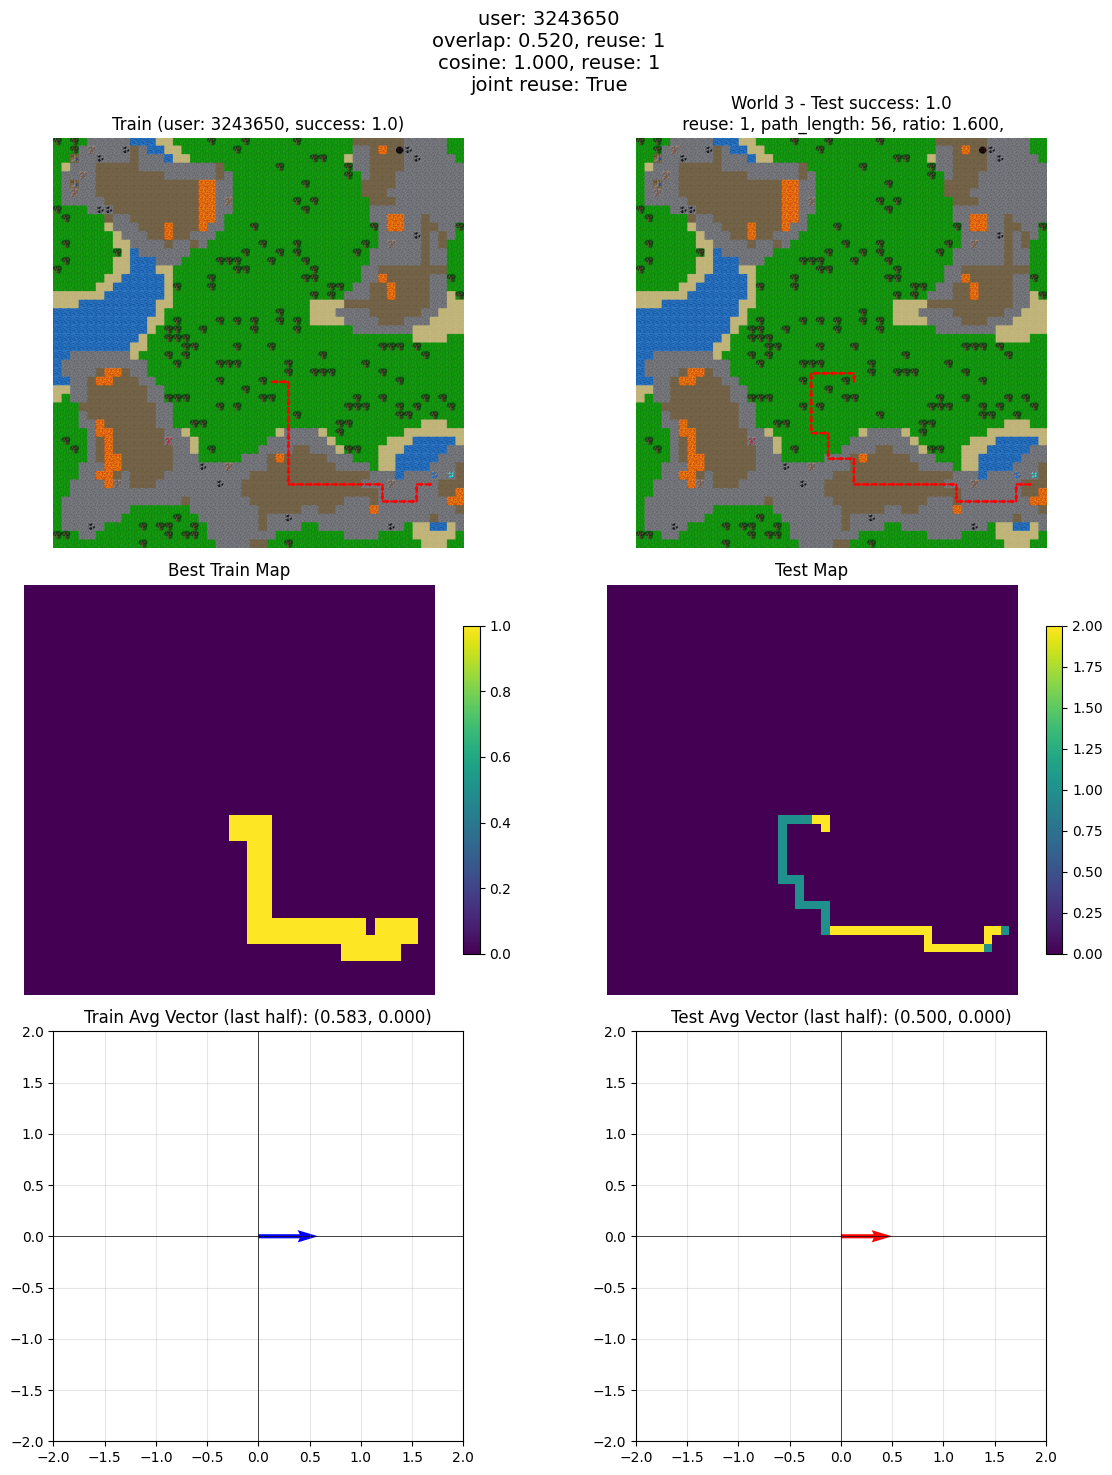

Saved figure to ../preplay_results/analysis_figures/craftax_overlap_analysis/paths_0.2_0.5/human_world_3/above_threshold_example_02_world_3_overlap_0.579_reuse_1.pdf


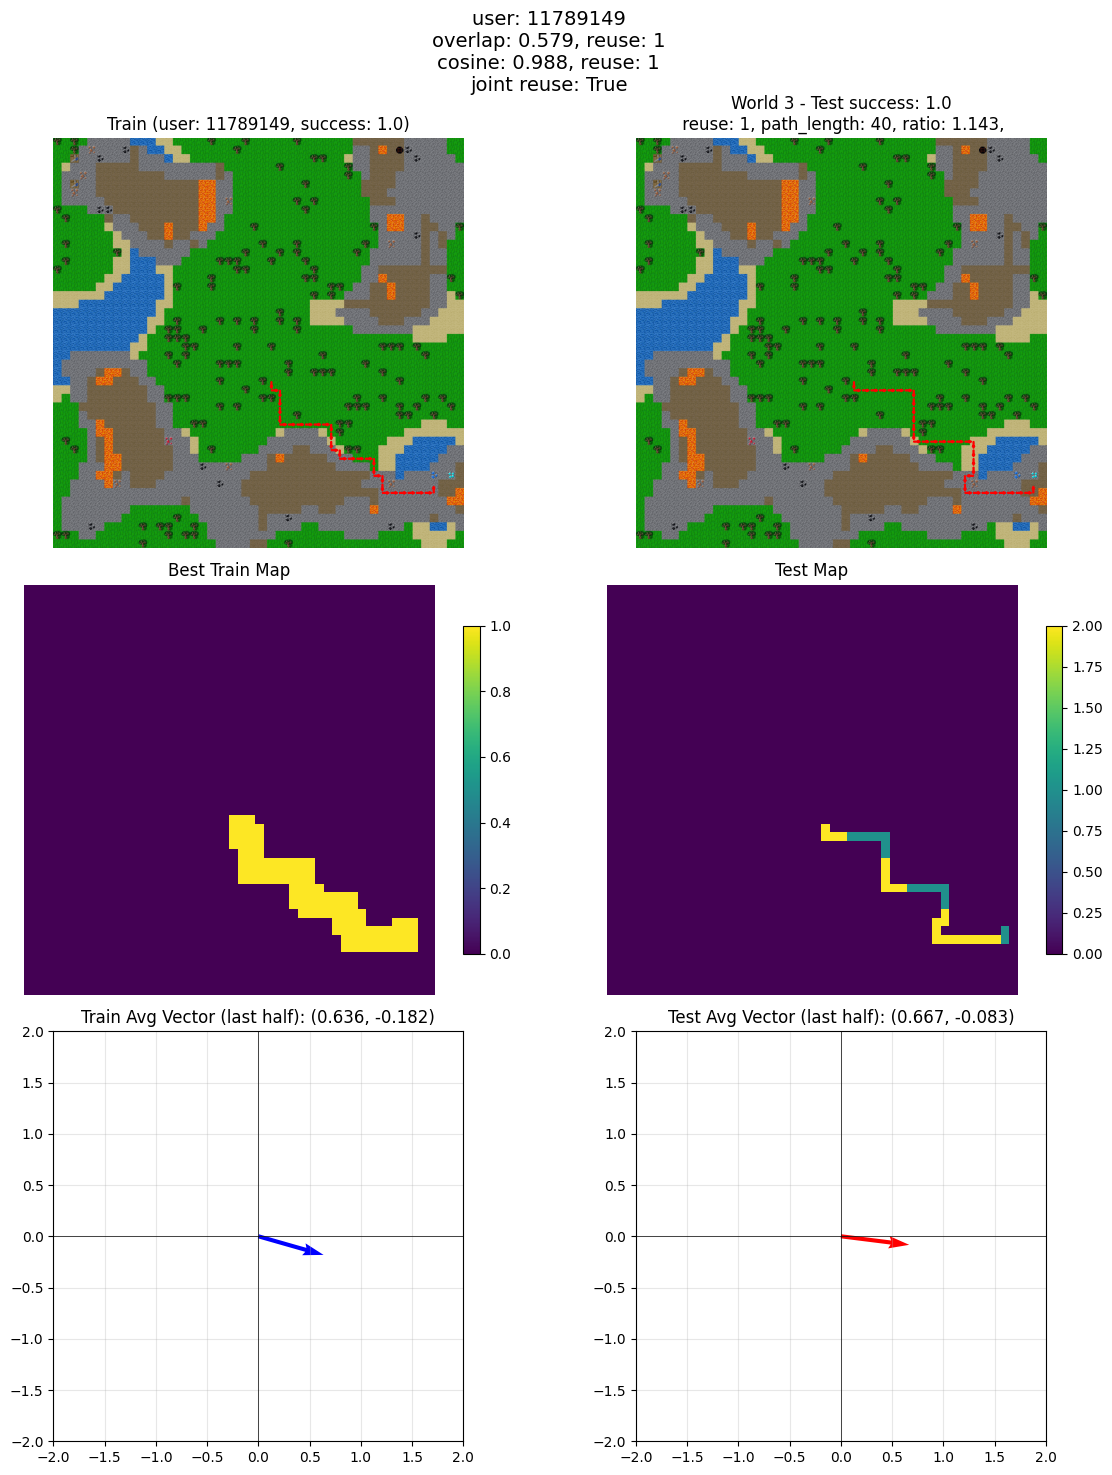

Saved figure to ../preplay_results/analysis_figures/craftax_overlap_analysis/paths_0.2_0.5/human_world_3/above_threshold_example_03_world_3_overlap_0.722_reuse_1.pdf


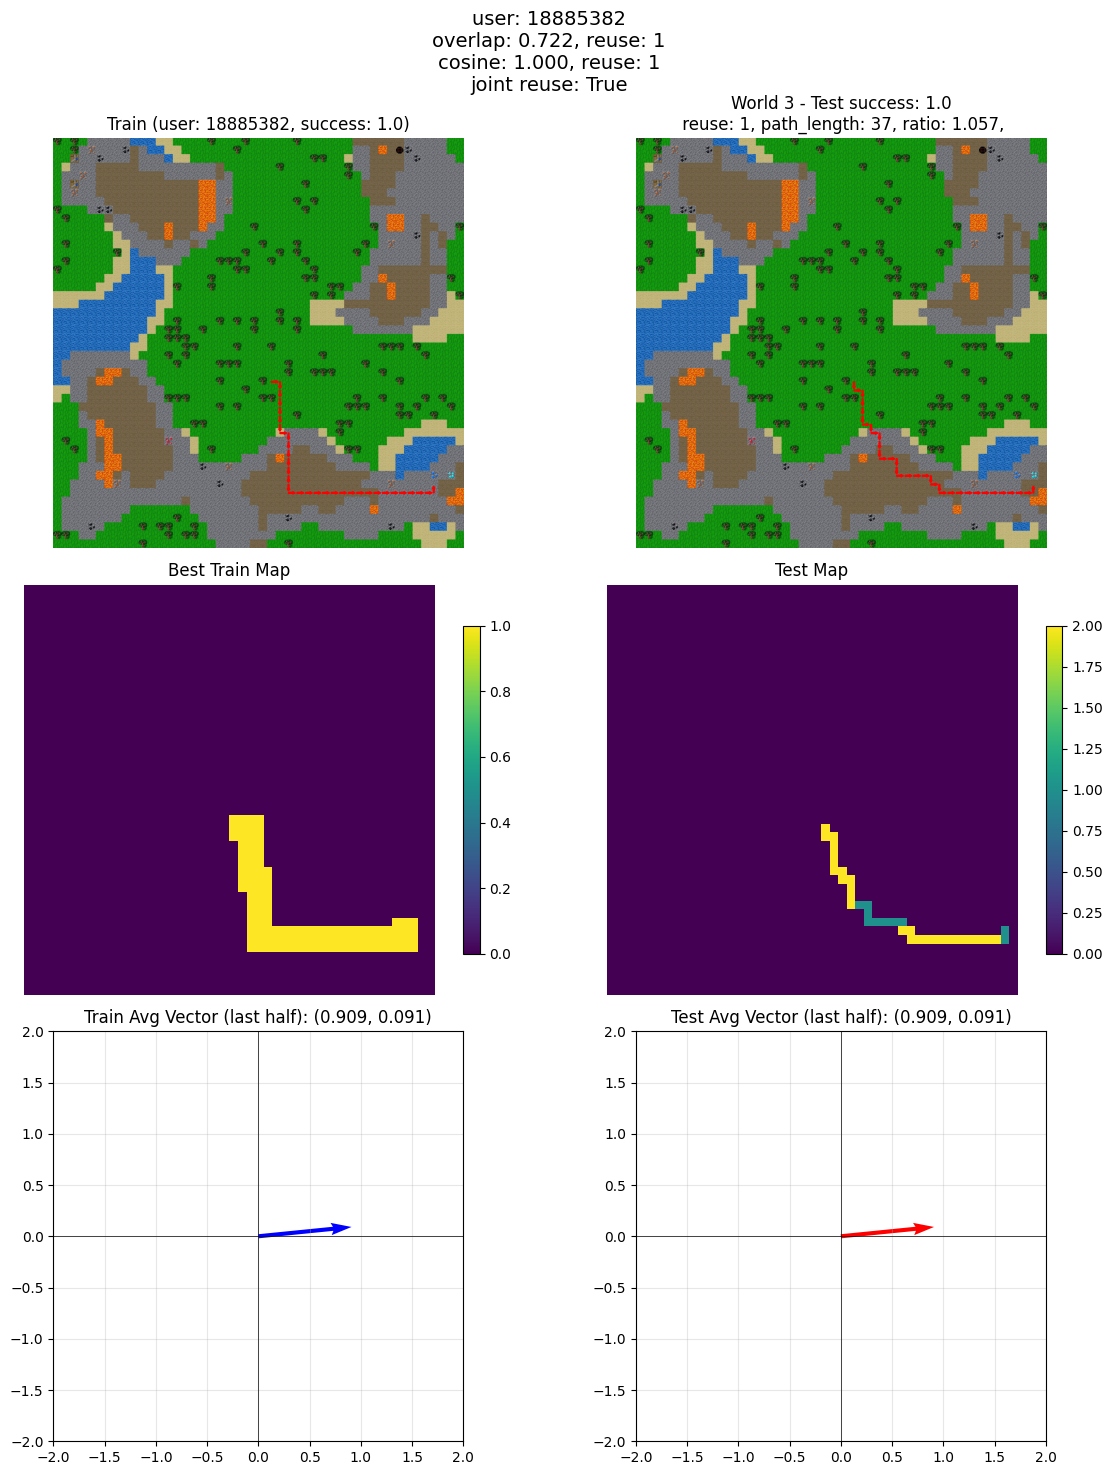

Saved figure to ../preplay_results/analysis_figures/craftax_overlap_analysis/paths_0.2_0.5/human_world_3/above_threshold_example_04_world_3_overlap_0.750_reuse_1.pdf


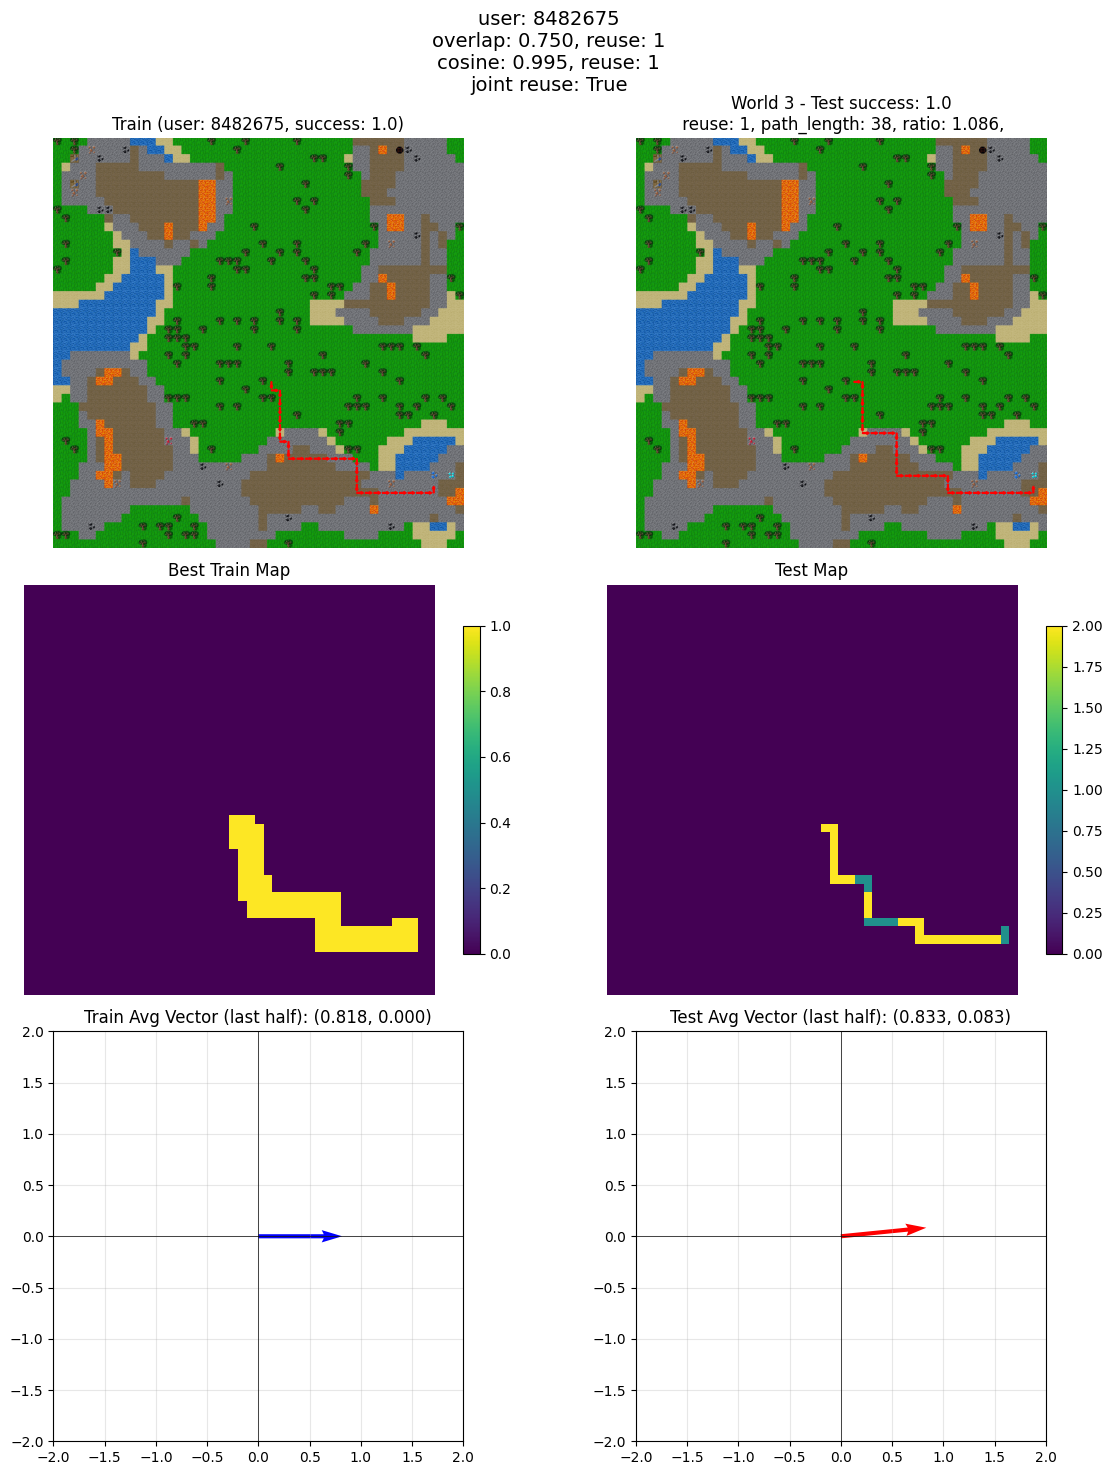

Saved figure to ../preplay_results/analysis_figures/craftax_overlap_analysis/paths_0.2_0.5/human_world_3/above_threshold_example_05_world_3_overlap_0.750_reuse_0.pdf


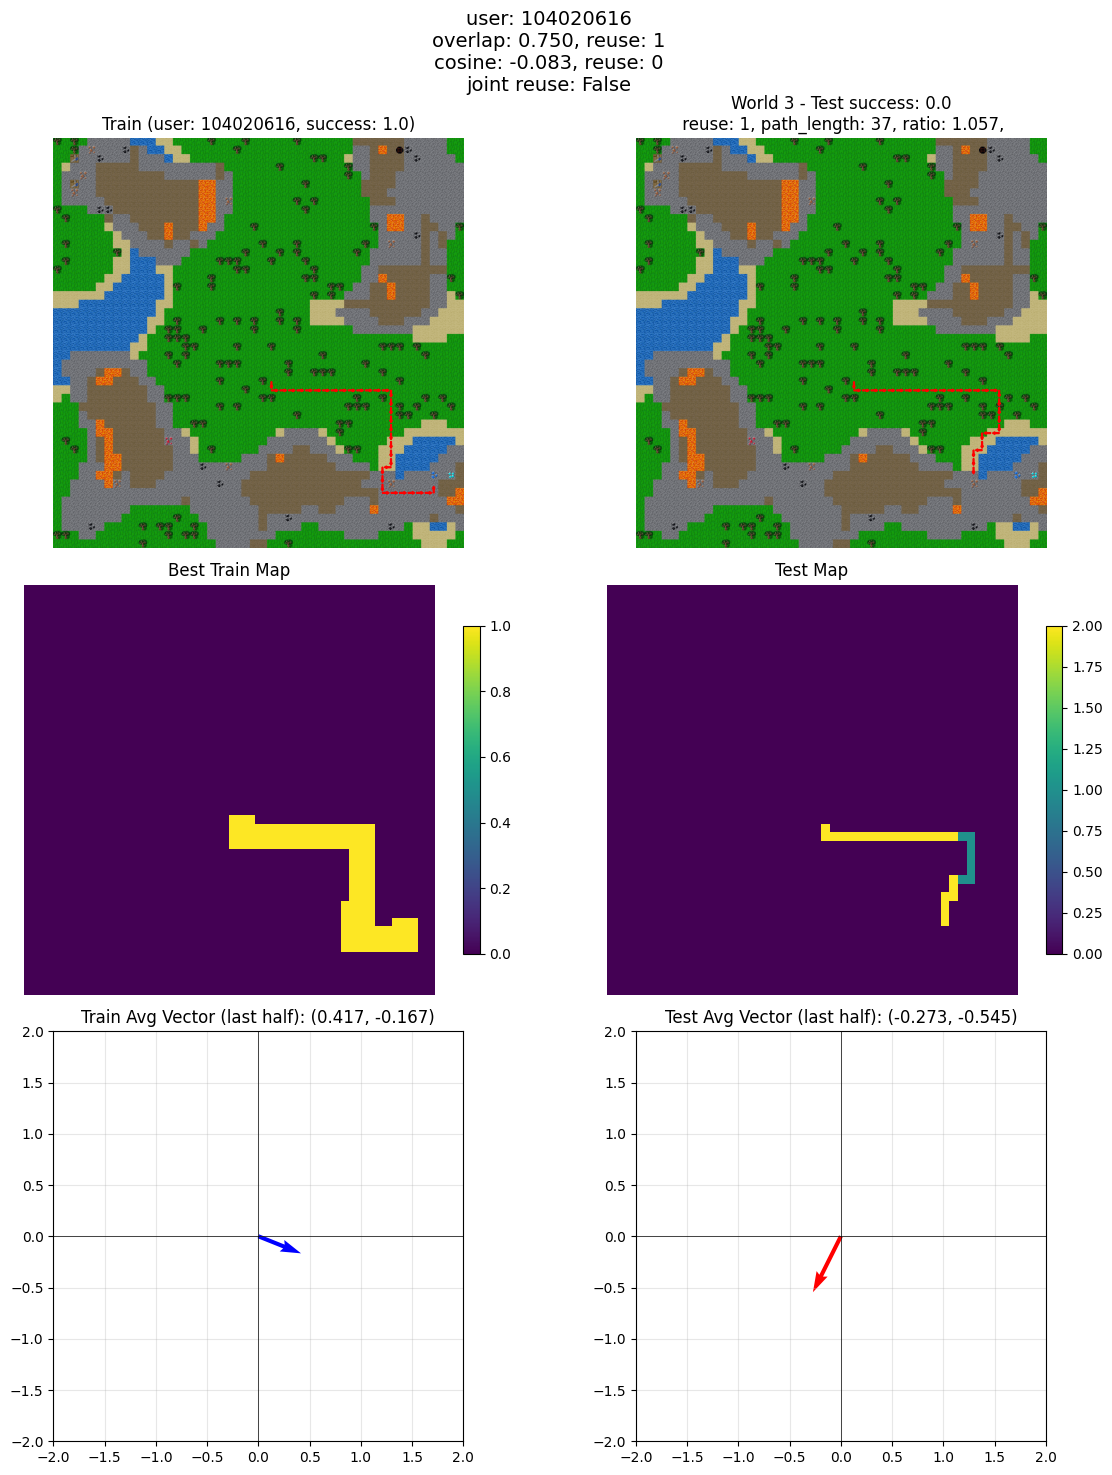

Saved figure to ../preplay_results/analysis_figures/craftax_overlap_analysis/paths_0.2_0.5/human_world_3/above_threshold_example_06_world_3_overlap_0.912_reuse_1.pdf


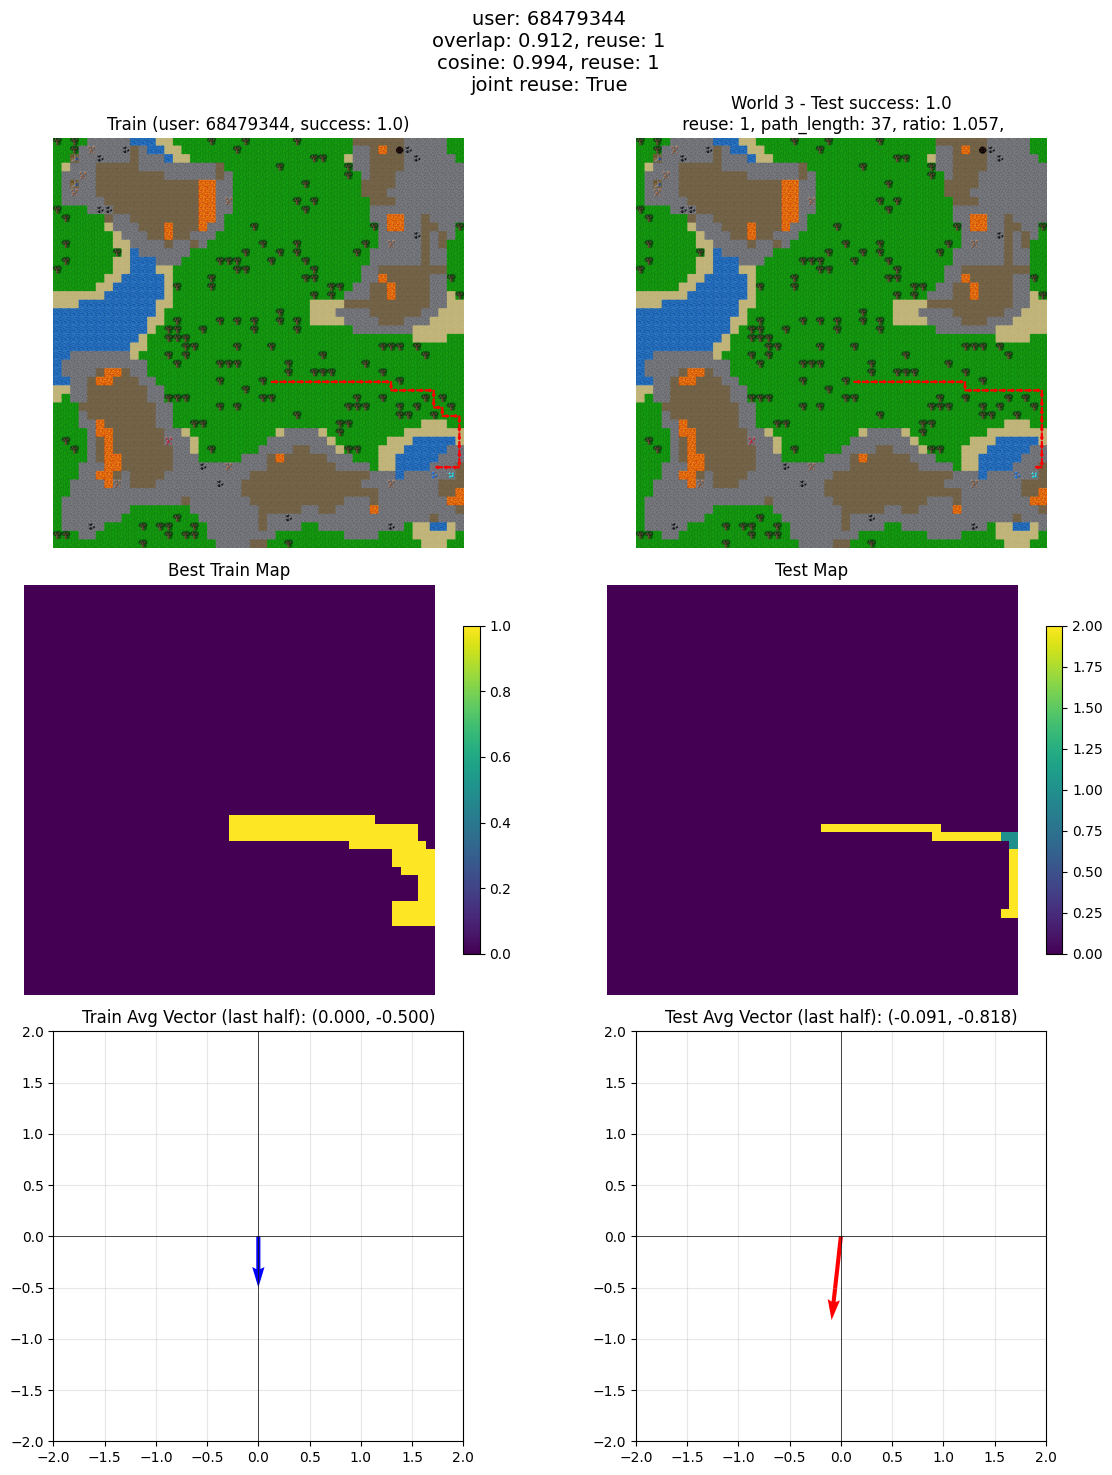

Saved figure to ../preplay_results/analysis_figures/craftax_overlap_analysis/paths_0.2_0.5/human_world_3/above_threshold_example_07_world_3_overlap_0.944_reuse_1.pdf


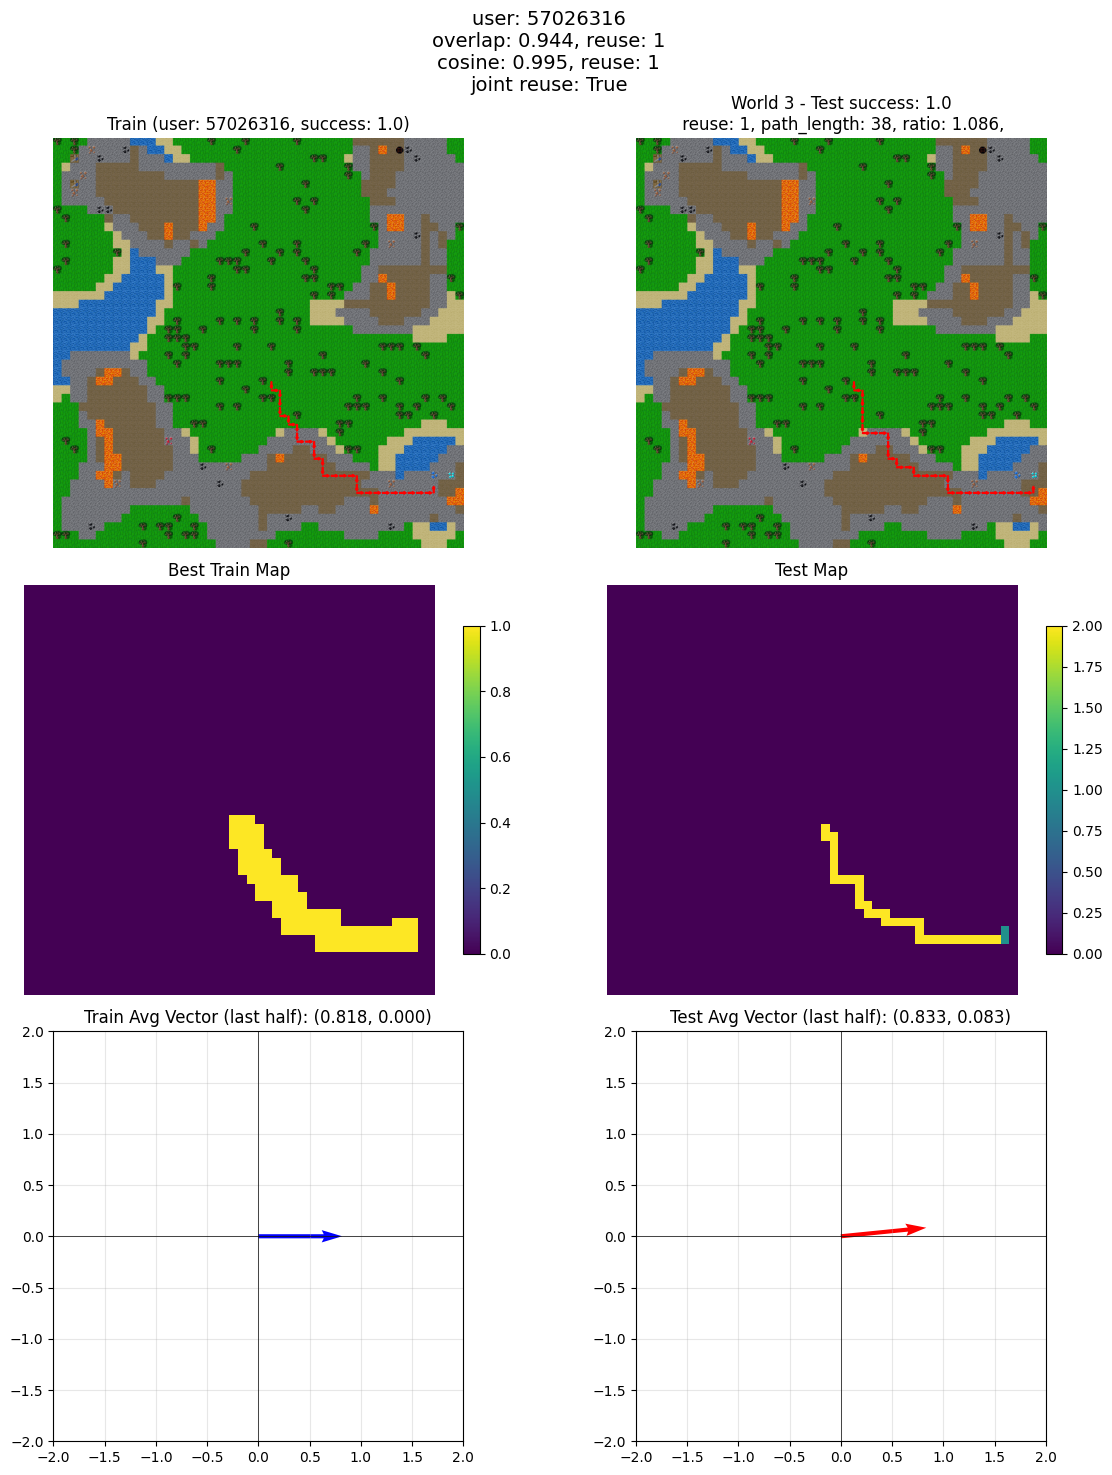

Saved figure to ../preplay_results/analysis_figures/craftax_overlap_analysis/paths_0.2_0.5/human_world_3/above_threshold_example_08_world_3_overlap_0.972_reuse_1.pdf


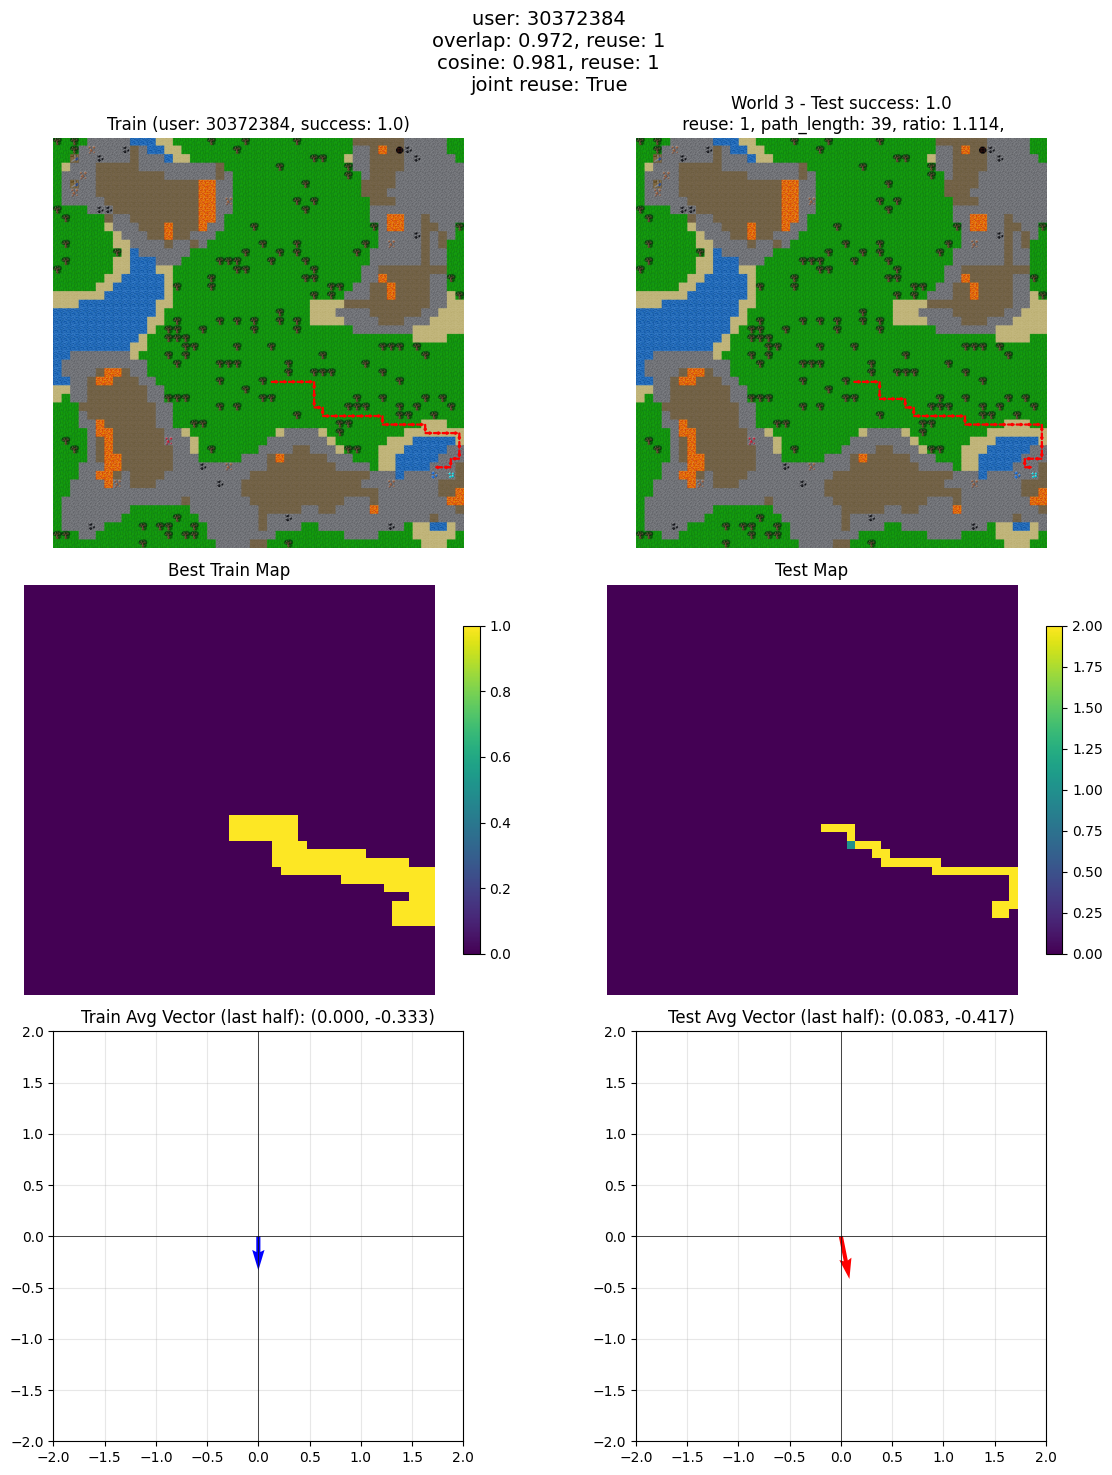

Saved figure to ../preplay_results/analysis_figures/craftax_overlap_analysis/paths_0.2_0.5/human_world_3_above_ratio/below_threshold_example_01_world_3_overlap_0.119_reuse_0.pdf


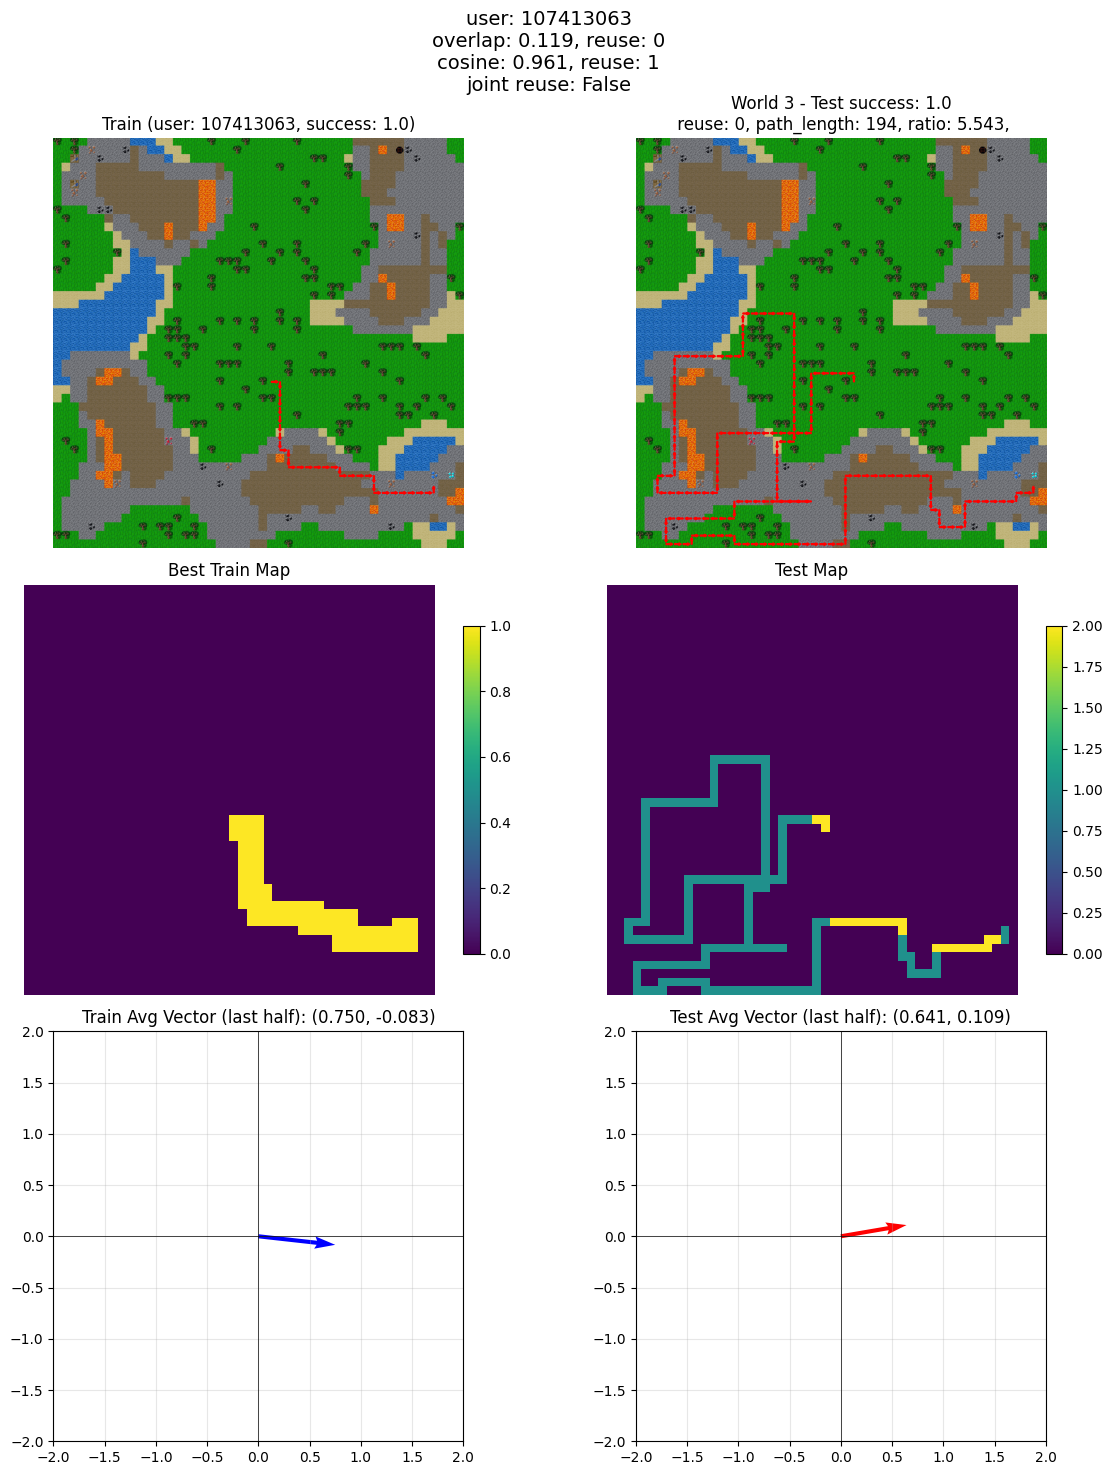

[{'key': 3243650,
  'train': <nicewebrl.dataframe.DataFrame at 0x7dfe4d5a0>,
  'test': <nicewebrl.dataframe.DataFrame at 0x7dfe4c850>,
  'train_map': array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]]], dtype=int32),
  'test_map': array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]]], dtype=int32),
  'cosine': 0.9938837346736189,
  'df_overlap': 0.52,
  'best_idx': 0,
  'filters': {'start_pos': '[28 25]',
   'block_name': '3',
   'user_id': 3243650,
   'task_set': 0},
  'world_seed': '3',
  'ratio_optimal_test_path': 1.6,
  'reuse': 1},
 {'key': 8482675,
  'train': <nicewebrl.dataframe.DataFrame at 0x7dfe4dfc0>,
  'test': <nicewebrl.dataframe.DataFra

In [16]:
# WORLD: 3
samples = visualize_human(
  world_seed=3, threshold=0.2, n_examples=5, max_tries=10, display_image=True
)

Block Names:   0%|                                                                                                         | 0/4 [00:00<?, ?it/s]


human - paths - threshold 0.2:
  World seed: 15
  Found 0 examples with overlap >= 0.2
  Found 1 examples with overlap < 0.2
Saved figure to ../preplay_results/analysis_figures/craftax_overlap_analysis/paths_0.2_0.5/human_world_15_above_ratio/below_threshold_example_01_world_15_overlap_0.492_reuse_0.pdf


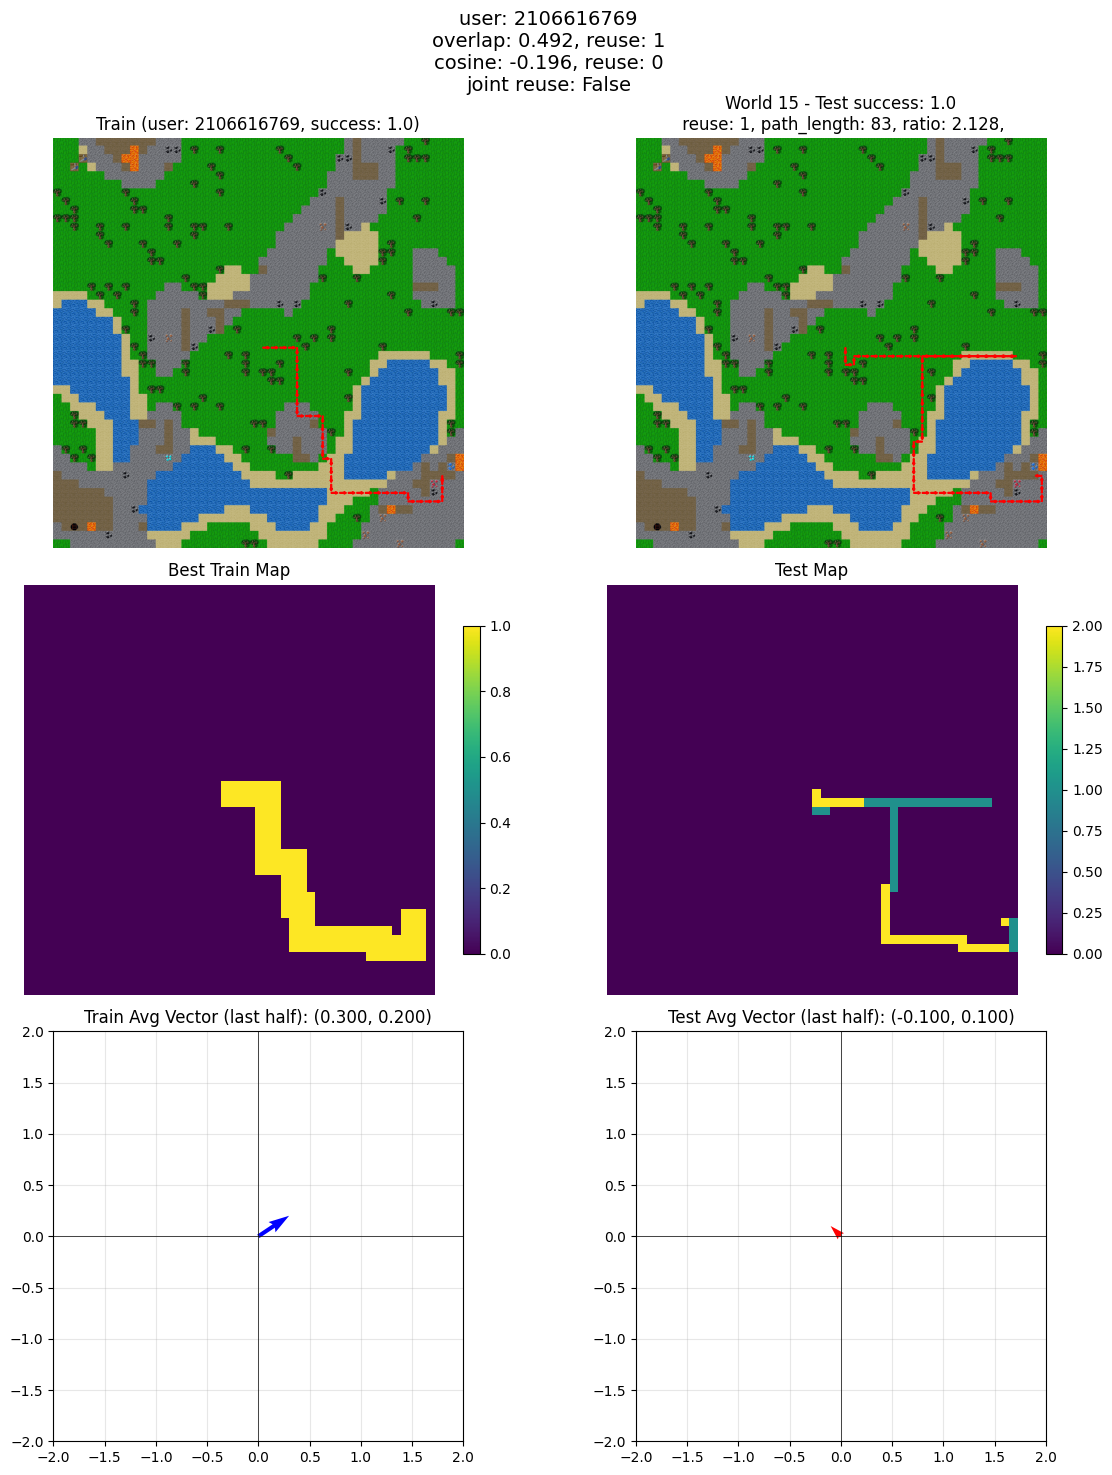

In [24]:
# %debug
from craftax_overlap_analysis import visualize_computations

world_seed = 15
samples = parse_and_compute_overlaps(
  df=user_df,
  manipulation="paths",
  model="human",
  world_seed=world_seed,
  manual_user_id=2106616769,
  debug=1,
)
visualize_from_samples(
  samples=samples,
  threshold=0.2,
  model="human",
  manipulation="paths",
  world_seed=world_seed,
  clear_output_dir=False,
  display_image=True,
)

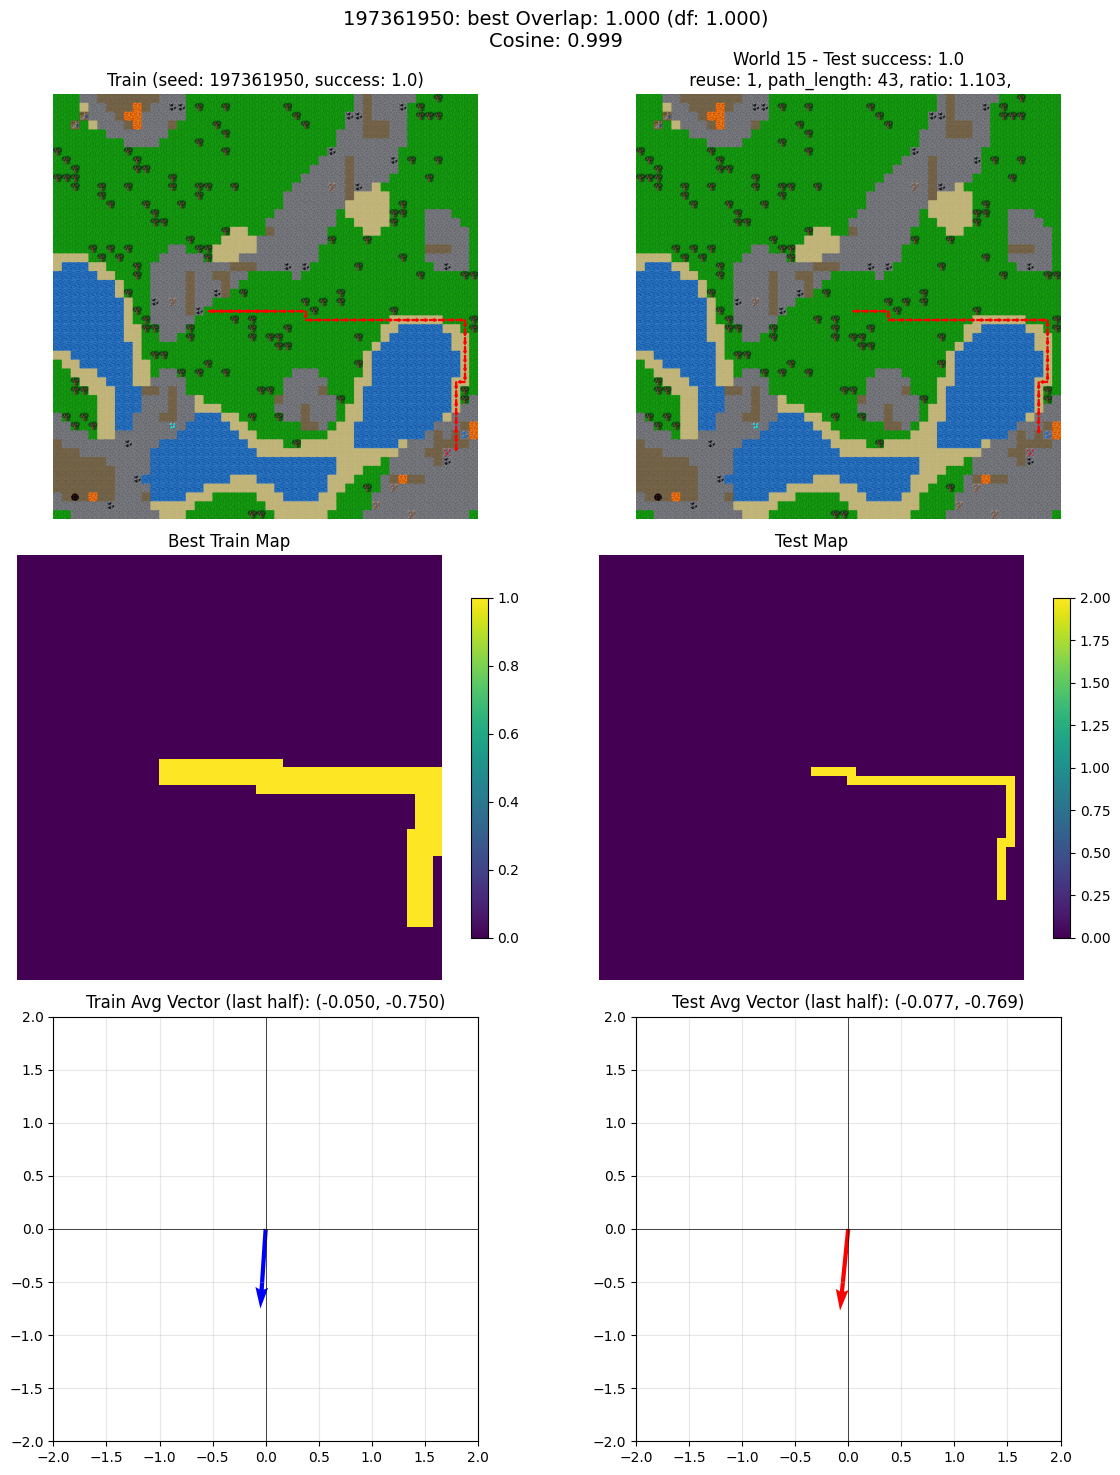

In [26]:
# %debug

fig = visualize_computations(data, threshold=0.2)